## 1. Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV
df = pd.read_csv(r"D:\JN\PythonForPractice\sales-performance-analysis\sales_dataset_1000_records.csv")

df.head()

,Order_ID,Order_Date,Product_Name,Category,Region,Quantity,Unit_Price,Revenue
0,ORD00001,06/06/2024,Product_10,Home,West,7,130.50,913.50
1,ORD00002,02/01/2024,Product_27,Home,Central,3,277.16,831.48
2,ORD00003,22/11/2024,Product_6,Clothing,Central,9,113.64,1022.76
3,ORD00004,17/05/2024,Product_20,Clothing,Central,2,295.88,591.76
4,ORD00005,11/04/2024,Product_22,Sports,East,6,134.32,805.92


## 2. Data Cleaning

In [2]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Fill numeric columns with median
for col in ['Quantity', 'Unit_Price', 'Revenue']:
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        df[col].fillna(df[col].median())

# Fill categorical columns with mode
for col in ['Product_Name', 'Category', 'Region']:
    if col in df.columns:
        mode_val = df[col].mode()
        if not mode_val.empty:
            df[col].fillna(mode_val[0])

print('Missing Values After Cleaning:')
print(df.isnull().sum())

Missing Values After Cleaning:
Order_ID        0
Order_Date      0
Product_Name    0
Category        0
Region          0
Quantity        0
Unit_Price      0
Revenue         0
dtype: int64


## 3. Total Revenue

In [3]:
total_revenue = df['Revenue'].sum()
print(f'Total Revenue: ${total_revenue}')

Total Revenue: $1377633.79


## 4. Average Order Value

In [4]:
avg_order_value = df['Revenue'].mean()
print(f'Total Orders: {len(df)}')
print(f'Average Order Value: ${avg_order_value}')

Total Orders: 1000
Average Order Value: $1377.63379


## 5. Monthly Growth Rate

In [5]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Month'] = df['Order_Date'].dt.to_period('M')
# print(df['Month'])

monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_growth = monthly_revenue.pct_change() * 100

print('\nMonthly Revenue & Growth Rate:')
monthly_summary = pd.DataFrame({
    'Revenue ($)': monthly_revenue,
    'Growth (%)' : monthly_growth
})
print(monthly_summary.to_string())


Monthly Revenue & Growth Rate:
         Revenue ($)  Growth (%)
Month                           
2024-01    104195.63         NaN
2024-02    119578.71   14.763652
2024-03    113091.35   -5.425180
2024-04    141063.41   24.734040
2024-05     87951.75  -37.650912
2024-06    135637.59   54.218182
2024-07     90805.87  -33.052578
2024-08    160243.99   76.468757
2024-09     97594.19  -39.096505
2024-10    126478.38   29.596219
2024-11    111554.91  -11.799226
2024-12     89438.01  -19.826021


## 6. Bar Chart – Top 10 Products by Revenue

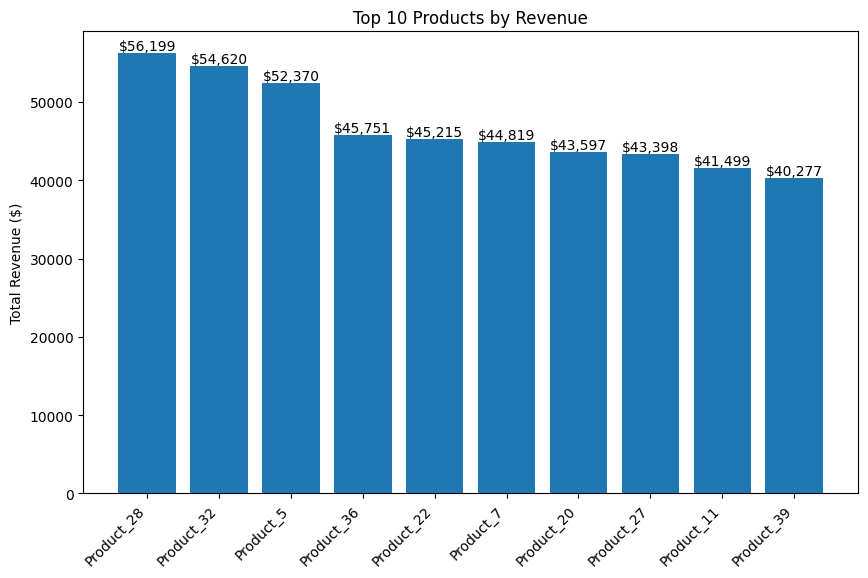

In [6]:
top10 = df.groupby('Product_Name')['Revenue'].sum().nlargest(10)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(top10.index, top10.values)
ax.bar_label(bars, fmt='${:,.0f}')

ax.set_ylabel('Total Revenue ($)')
ax.set_title('Top 10 Products by Revenue')

plt.xticks(rotation=45, ha='right')

plt.savefig('bar_chart.png', bbox_inches='tight')
plt.show()

## 7. Line Chart – Monthly Revenue Trend

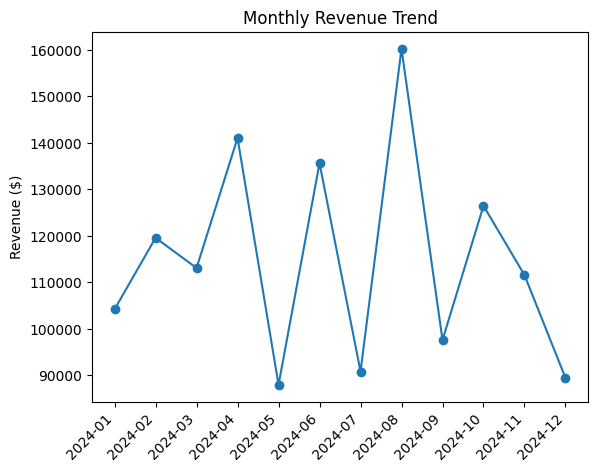

In [ ]:
monthly_revenue = monthly_revenue.reset_index()

monthly_revenue['Month_Str'] = monthly_revenue['Month'].dt.to_timestamp().dt.strftime('%Y-%m')
fig, ax = plt.subplots()
ax.plot(monthly_revenue['Month_Str'], monthly_revenue['Revenue'], marker='o')

ax.set_ylabel('Revenue ($)')
ax.set_title('Monthly Revenue Trend')

plt.xticks(rotation=45, ha='right')

plt.savefig('line_chart.png', bbox_inches='tight')
plt.show()

## 8. Heatmap – Region vs Revenue

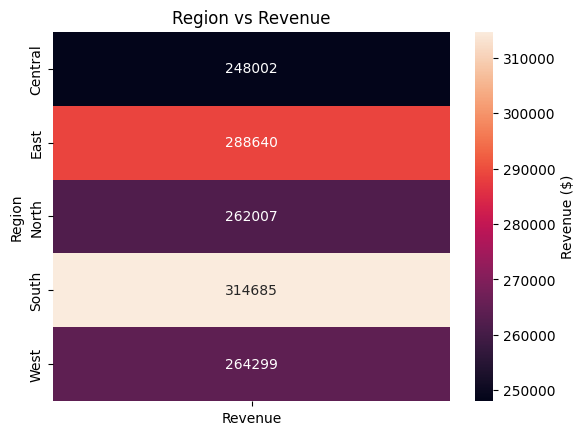

In [8]:
region_rev = df.groupby('Region')['Revenue'].sum().to_frame()

fig, ax = plt.subplots()
sns.heatmap(region_rev, annot=True, fmt='.0f', cbar_kws={'label':'Revenue ($)'}, ax=ax)
ax.set_title('Region vs Revenue')

plt.savefig('heatmap.png', bbox_inches='tight')
plt.show()

## 6. Dashboard – Combined Overview

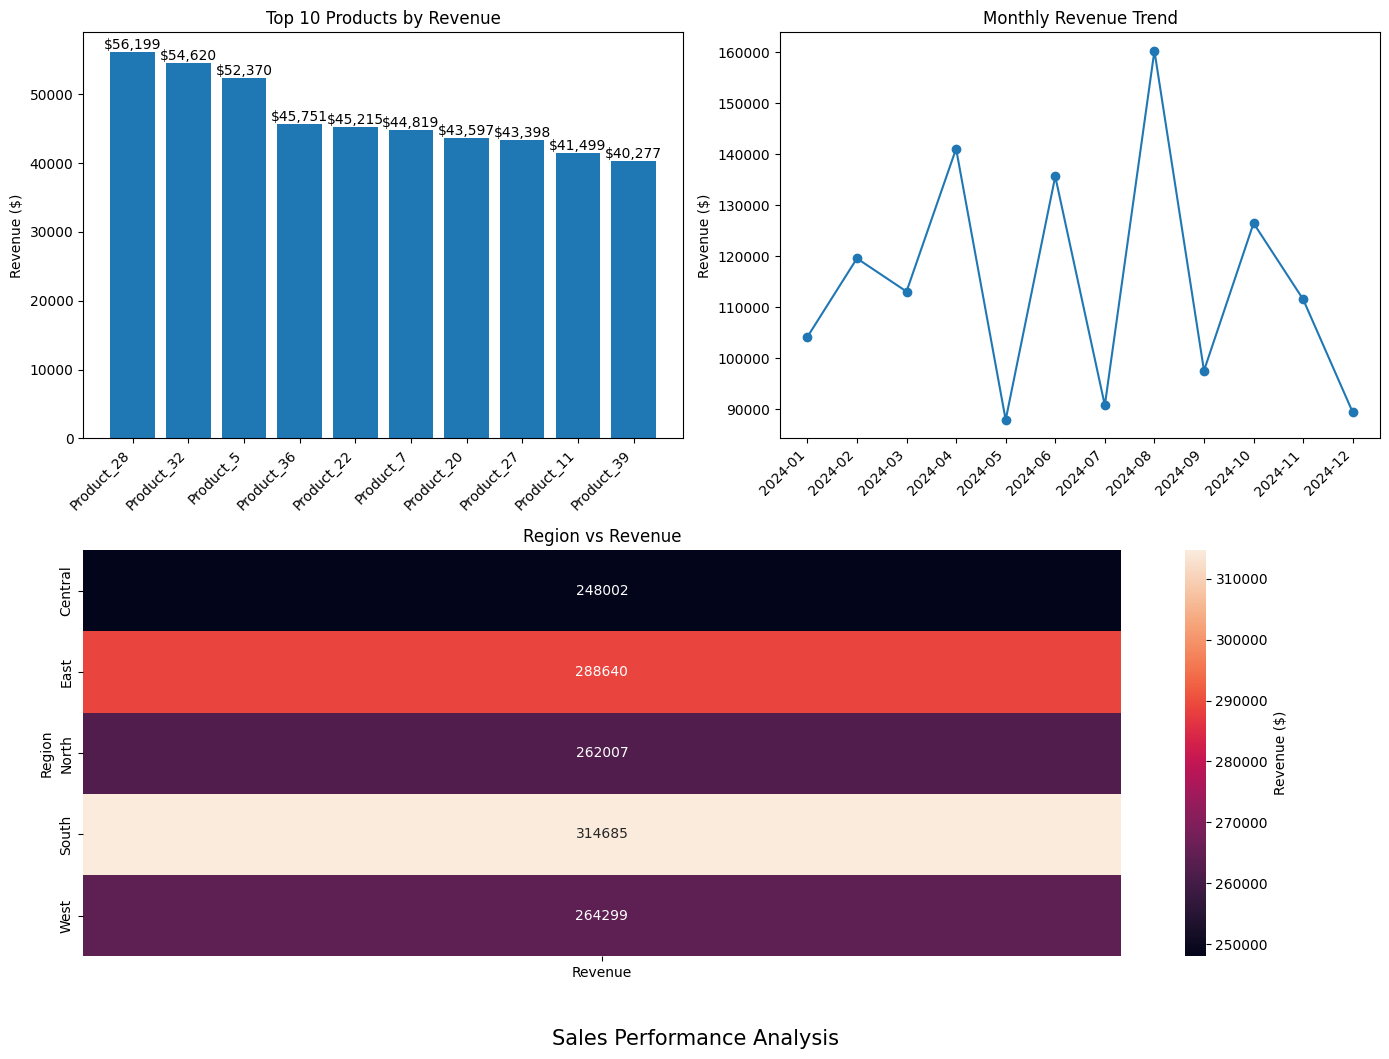

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Top 10 Products by Revenue (Bar Chart) ──
top10 = df.groupby('Product_Name')['Revenue'].sum().nlargest(10)

# ── Monthly Revenue Trend (Line Chart) ──
monthly_revenue = monthly_revenue.reset_index()

monthly_revenue['Month_Str'] = monthly_revenue['Month'].astype(str)

# ── Region Revenue (Heatmap) ──
region_rev = df.groupby('Region')['Revenue'].sum().to_frame()

# ── Dashboard Figure ──
fig = plt.figure(figsize=(14, 10))

# Bar Chart
ax1 = fig.add_subplot(2, 2, 1)
bars = ax1.bar(top10.index, top10.values)
ax1.bar_label(bars, fmt='${:,.0f}')
ax1.set_ylabel('Revenue ($)')
ax1.set_title('Top 10 Products by Revenue')
plt.sca(ax1)
plt.xticks(rotation=45, ha='right')

# Line Chart
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(monthly_revenue['Month_Str'], monthly_revenue['Revenue'], marker='o')
ax2.set_ylabel('Revenue ($)')
ax2.set_title('Monthly Revenue Trend')
plt.sca(ax2)
plt.xticks(rotation=45, ha='right')

# Heatmap (spans full width at bottom)
ax3 = fig.add_subplot(2, 1, 2)
sns.heatmap(region_rev, annot=True, fmt='.0f', cbar_kws={'label':'Revenue ($)'}, ax=ax3)
ax3.set_title('Region vs Revenue')

plt.tight_layout()
fig.text(0.5, -0.05, 'Sales Performance Analysis',
         ha='center', fontsize=15)
plt.savefig('dashboard.png', bbox_inches='tight')
plt.show()